In [5]:
import importlib
import matplotlib.pyplot as plt
import pandas as pd
import pickle
import sys

# performance imports for torch: torch kernel uses one core only.
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["TORCH_NUM_THREADS"] = "1" 

import torch

sys.path.insert(0, '..')
sys.path.insert(0, '../..')
sys.path.insert(0, '../../..')
sys.path.insert(0, '../../../..')
sys.path.insert(0, '../../../../..')
sys.path.insert(0, '../../../../../..')

# Decision labeling runtime models
import data_processing.decision_labeling
importlib.reload(data_processing.decision_labeling)
from data_processing.decision_labeling import DecisionLabeler

# Model
import suffix_pred.models.C_LSTM
importlib.reload(suffix_pred.models.C_LSTM)
from suffix_pred.models.C_LSTM import FullShared_Join_LSTM

# decision-rul guided decoding and reasoning
import suffix_pred.decision_rule_guided_reasoning_inference
importlib.reload(suffix_pred.decision_rule_guided_reasoning_inference)
from suffix_pred.decision_rule_guided_reasoning_inference import DecisionGuidanceConfig, get_decision_guided_evaluator

# Evaluation metrics
import suffix_pred.evalaution.evalaution_metrics
importlib.reload(suffix_pred.evalaution.evalaution_metrics)
from suffix_pred.evalaution.evalaution_metrics import evaluate_dls, dls_per_prefix_length, average_dls

In [ ]:
# Model
# Model clean:
file_path_model = '../../../../../../models/BPIC20_DD/clean/BPIC20_DD_C_LSTM_v1_clean.pkl'

model = FullShared_Join_LSTM.load(file_path_model)

# Load the data: Use for eval alway the clean test data:
file_path_test = '../../../../../../data/BPIC20_DD/tensor_data/normal/bpic20_dd_all_5_test.pkl'
test_dataset = torch.load(file_path_test, weights_only=False)

# Decision mining artifacts for runtime decision guidance
petri_net_path = '../../../../../../data/BPIC20_DD/Petri_net/bpic20_dd.pkl'
decision_bundle_path = '../../../../../../data/BPIC20_DD/Petri_net/data_aware_Petri_net/decision_places_bundle.json'
decision_model_dir = '../../../../../../data/BPIC20_DD/Petri_net/data_aware_Petri_net/models'

with open(petri_net_path, 'rb') as f:
    net, im, fm = pickle.load(f)

# Attributes must match decision model
dynamic_attributes = ["org:resource",
                          "amount",
                          "budget_status",
                          "revision_count",
                          "supplier_type",
                          "goods_match",
                          "invoice_deviation_pct",
                          "case_elapsed_time",
                          "event_elapsed_time"]

# same across the whole trace
static_attributes = ["requester_seniority",
                      "department",
                      "category",
                      "priority"]

# 
decision_labeler = DecisionLabeler(petri_net=(net, im, fm),
                                   decision_model_dir=decision_model_dir,
                                   decision_places_bundle_path=decision_bundle_path,
                                   dynamic_attributes=dynamic_attributes,
                                   static_attributes=static_attributes)

# 
guidance_cfg = DecisionGuidanceConfig(epsilon=1e-3,
                                      beta_max=2.0,
                                      alpha=0.10,
                                      support_threshold=0.05)

print('Model and decision guidance artifacts loaded.')

Data set categories:  ([('concept:name', 10, {'Declaration APPROVED': 1, 'Declaration FINAL_APPROVED': 2, 'Declaration FOR_APPROVAL': 3, 'Declaration REJECTED': 4, 'Declaration SAVED': 5, 'Declaration SUBMITTED': 6, 'EOS': 7, 'Payment Handled': 8, 'Request Payment': 9}), ('org:resource', 4, {'EOS': 1, 'STAFF MEMBER': 2, 'SYSTEM': 3}), ('org:role', 9, {'ADMINISTRATION': 1, 'BUDGET OWNER': 2, 'EMPLOYEE': 3, 'EOS': 4, 'MISSING': 5, 'PRE_APPROVER': 6, 'SUPERVISOR': 7, 'UNDEFINED': 8})], [('case_elapsed_time', 1, {}), ('event_elapsed_time', 1, {}), ('day_in_week', 1, {}), ('seconds_in_day', 1, {})])
Model input features:  [['concept:name', 'org:resource'], ['case_elapsed_time']]


Embeddings:  ModuleList(
  (0): Embedding(10, 6)
  (1): Embedding(4, 3)
)
Total embedding feature size:  9
Input feature size:  10
Cells hidden size:  50
Number of LSTM layer:  1
Model and decision guidance artifacts loaded.


/home/PSPLab/.local/share/virtualenvs/decision_aware_augmentation_for_PPM-0DzgvVpC/lib/python3.12/site-packages/torch/nn/modules/rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


In [7]:

# Step 1: Guided decode suffixes (mode / arg-max with local decision reweighting)
guided_mode_eval = get_decision_guided_evaluator(kind='mode',
                                                 model=model,
                                                 dataset=test_dataset,
                                                 decision_labeler=decision_labeler,
                                                 guidance_config=guidance_cfg,
                                                 decision_places_bundle_path=decision_bundle_path,
                                                 concept_name='concept:name',
                                                 eos_value='EOS')

guided_mode_outputs = []
guided_mode_reasoning = []

# evaluate the (decision) cases
for case_id, prefix_len, prefix, target_suffix, decoded_suffixes, reasoning in guided_mode_eval.evaluate(random_order=False,                                                                                                    return_reasoning=True):
    guided_mode_outputs.append({'case_id': case_id,
                                'prefix_len': int(prefix_len),
                                'prefix': prefix,
                                'target_suffix': target_suffix,
                                'decoded_suffixes': decoded_suffixes,
                                'mode': 'guided_mode'})
    
    guided_mode_reasoning.append({'case_id': case_id,
                                  'prefix_len': int(prefix_len),
                                  'reasoning': reasoning})

cache_outputs_path = '../../../../../../eval_results/BPIC20_DD/decision_decoding/bpic20_dd_c_lstm_decision_guided_outputs.pkl'
# cache_outputs_path = '../../../../../../eval_results/BPIC20_DD/decision_train_and_decoding/bpic20_dd_c_lstm_decision_train_and_decision_guided_mode_outputs.pkl'

cache_reasoning_path = '../../../../../../eval_results/BPIC20_DD/decision_decoding/bpic20_dd_c_lstm_decision_guided_reasoning.pkl'
# cache_reasoning_path = '../../../../../../eval_results/BPIC20_DD/decision_train_and_decoding/bpic20_dd_c_lstm_decision_train_and_decision_guided_mode_reasoning.pkl'
 
with open(cache_outputs_path, 'wb') as f:
    pickle.dump(guided_mode_outputs, f)

with open(cache_reasoning_path, 'wb') as f:
    pickle.dump(guided_mode_reasoning, f)

print(f"Decoded {len(guided_mode_outputs)} prefix rows in 'guided_mode'.")

# Step 2: Evaluate DLS from guided decoded outputs
guided_mode_df = evaluate_dls(guided_mode_outputs)
guided_mode_per_prefix = dls_per_prefix_length(guided_mode_df)
guided_mode_avg = average_dls(guided_mode_df)

# Step 3: Aggregate decision and explanation diagnostics
decision_steps = sum(r['reasoning']['decision_steps'] for r in guided_mode_reasoning)
conflicts = sum(r['reasoning']['conflicts'] for r in guided_mode_reasoning)
explained_steps = sum(r['reasoning'].get('explained_steps', 0) for r in guided_mode_reasoning)

conflict_rate = (conflicts / decision_steps) if decision_steps > 0 else 0.0
explained_rate = (explained_steps / decision_steps) if decision_steps > 0 else 0.0

print(f"Average DLS (guided_mode) on full test set: {guided_mode_avg:.4f}")
print(f"Decision steps: {decision_steps} | Conflicts: {conflicts} | Conflict rate: {conflict_rate:.4f}")
print(f"Explained steps: {explained_steps} | Explained rate: {explained_rate:.4f}")


  0%|          | 0/2100 [00:00<?, ?it/s]

Decoded 9124 prefix rows in 'guided_mode'.
Average DLS (guided_mode) on full test set: 0.7684
Decision steps: 27861 | Conflicts: 2420 | Conflict rate: 0.0869
Explained steps: 6583 | Explained rate: 0.2363


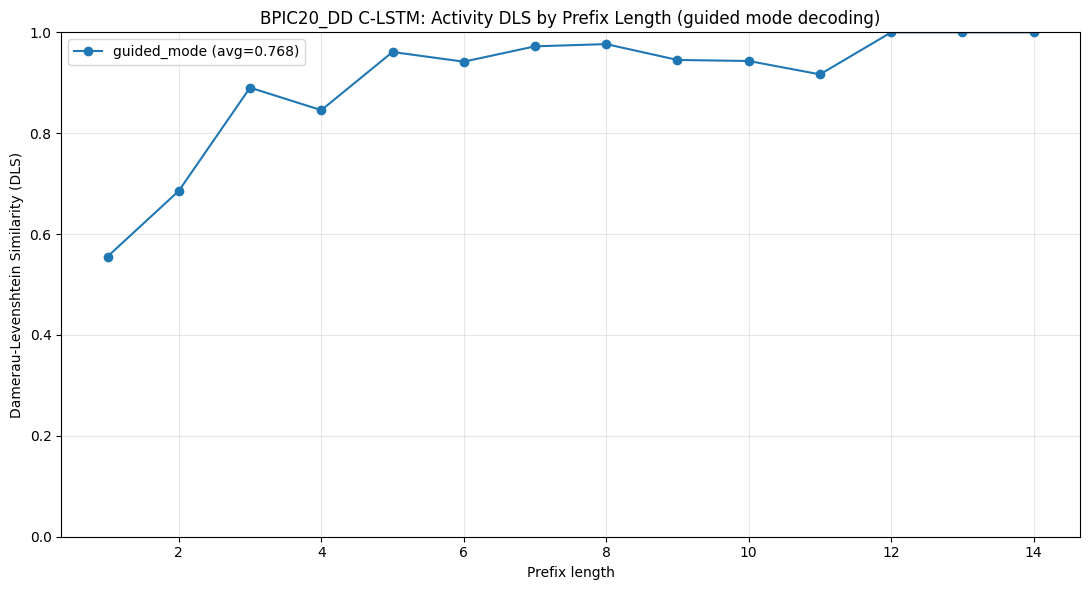

,mode,average_dls,decision_steps,conflicts,conflict_rate,explained_steps,explained_rate
0,guided_mode,0.768366,27861,2420,0.08686,6583,0.23628


In [8]:
# Plot DLS by prefix length for guided mode
plt.figure(figsize=(11, 6))

plt.plot(guided_mode_per_prefix['prefix_len'],
         guided_mode_per_prefix['dls'],
         marker='o',
         label=f"guided_mode (avg={guided_mode_avg:.3f})")

plt.title('BPIC20_DD C-LSTM: Activity DLS by Prefix Length (guided mode decoding)')
plt.xlabel('Prefix length')
plt.ylabel('Damerau-Levenshtein Similarity (DLS)')
plt.ylim(0.0, 1.0)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

summary = pd.DataFrame({
    'mode': ['guided_mode'],
    'average_dls': [guided_mode_avg],
    'decision_steps': [decision_steps],
    'conflicts': [conflicts],
    'conflict_rate': [conflict_rate],
    'explained_steps': [explained_steps],
    'explained_rate': [explained_rate],
}).sort_values('average_dls', ascending=False).reset_index(drop=True)
summary

In [9]:

# Inspect guided predictions and rule-based reasoning examples with per-attribute checks
with open('../../../../../../eval_results/BPIC20_DD/decision_decoding/bpic20_dd_c_lstm_decision_guided_outputs.pkl', 'rb') as f:
    cached_outputs = pickle.load(f)
    
with open('../../../../../../eval_results/BPIC20_DD/decision_decoding/bpic20_dd_c_lstm_decision_guided_reasoning.pkl', 'rb') as f:
    cached_reasoning = pickle.load(f)

for i in range(min(100, len(cached_outputs))):
    row = cached_outputs[i]
    reason = cached_reasoning[i]['reasoning']

    print(f"Case: {row['case_id']}  |  Prefix len: {row['prefix_len']}")
    print(f"  Prefix:            {row['prefix']}")
    print(f"  Target suffix:     {row['target_suffix']}")
    decoded = row['decoded_suffixes']
    print(f"  Predicted suffix:  {decoded[0] if len(decoded) > 0 else []}")
    print(f"  Decision steps: {reason['decision_steps']} | Conflicts: {reason['conflicts']} | Conflict rate: {reason['conflict_rate']:.4f}")
    print(f"  Explained steps: {reason.get('explained_steps', 0)} | Explained rate: {reason.get('explained_rate', 0.0):.4f}")

    trace = reason.get('trace', [])
    if len(trace) == 0:
        print("  No supported rule-aligned reasoning step.")
        print()
        continue

    for step in trace[:3]:
        decision_top = step.get('decision_top_event')
        decision_top_prob = step.get('decision_top_prob')
        next_event = step['next_event']
        model_prob = step.get('model_prob')
        model_prob_str = f"{model_prob:.1%}" if model_prob is not None else "?"

        if decision_top is not None and decision_top != next_event:
            # Decision model's top pick differs from what the suffix predictor chose
            top_prob_str = f"p={decision_top_prob:.1%}" if decision_top_prob is not None else "p=?"
            print(f"  Decision step {step['step']}: {step['input_event']} -> "
                  f"{decision_top} ({top_prob_str}, decision top) at place {step['place']}, "
                  f"but with prob {model_prob_str} (model), {next_event} was predicted")
        else:
            top_prob_str = f", decision top p={decision_top_prob:.1%}" if decision_top_prob is not None else ""
            print(f"  Decision step {step['step']}: {step['input_event']} -> "
                  f"{next_event} (model prob: {model_prob_str}{top_prob_str}) at place {step['place']}")

        matched_rule = step.get('matched_rule')
        if matched_rule is not None:
            print(f"    Matched rule: {matched_rule.get('rule', '')}")

        attr_checks = step.get('attribute_checks', [])
        seen_attrs = set()
        if len(attr_checks) == 0:
            print("    No attribute checks available.")
        else:
            for chk in attr_checks:
                attr_name = chk.get('attr', '')
                attr_value = chk.get('value', None)
                dedup_key = (attr_name, attr_value)
                if dedup_key in seen_attrs:
                    continue
                seen_attrs.add(dedup_key)
                is_in_rule = bool(chk.get('in_rule_set', False))
                print(f"    - {attr_name}: value={attr_value} | in_rule_set={is_in_rule}")
    print()


Case: declaration 100027  |  Prefix len: 1
  Prefix:            ['Declaration SUBMITTED']
  Target suffix:     ['Declaration APPROVED', 'Declaration FINAL_APPROVED', 'Request Payment', 'Payment Handled']
  Predicted suffix:  ['Declaration REJECTED', 'Declaration REJECTED', 'Declaration SUBMITTED', 'Declaration APPROVED', 'Declaration FINAL_APPROVED', 'Request Payment', 'Payment Handled']
  Decision steps: 7 | Conflicts: 0 | Conflict rate: 0.0000
  Explained steps: 1 | Explained rate: 0.1429
  Decision step 0: Declaration SUBMITTED -> Declaration REJECTED (model prob: 76.0%, decision top p=64.4%) at place p_15
    No attribute checks available.
  Decision step 1: Declaration REJECTED -> Declaration REJECTED (model prob: 45.3%, decision top p=66.4%) at place p_7
    No attribute checks available.
  Decision step 2: Declaration REJECTED -> Declaration REJECTED (p=57.0%, decision top) at place p_7, but with prob 52.5% (model), Declaration SUBMITTED was predicted
    No attribute checks ava